<a href="https://colab.research.google.com/github/Chb3rri/Module_3_part_1/blob/main/SentimentAnalysisModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting the sentiment analysis model

This exercise was interesting to do. It should function well enough for now. I might modify it as i start to do the third module.

In [ ]:
import pandas as pd

In [ ]:
!pip install kagglehub

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rmustajrvi","key":"d476e75a5d7ec283673e00b28b328773"}'}

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!ls -ltr ~/.kaggle/

total 4
-rw------- 1 root root 66 Feb 22 07:03 kaggle.json


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset               Screen Time, Sleep & Stress Analysis Dataset            787136  2026-02-13 06:56:18.757000           4178         83  1.0              
amar5693/student-performance-dataset                                 Student Performance Dataset                             177286  2026-02-12 06:04:44.613000           3755         62  1.0              
aliiihussain/amazon-sales-dataset                                    Amazon_Sales_Dataset                                   1297759  2026-02-01 11:37:12.353000           7362      

In [ ]:
import kagglehub
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")

print("Path to dataset files:",path)

Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-dataset


In [ ]:
ls -ltr ../kaggle/input/sentiment-analysis-dataset

total 147288
-rw-r--r-- 1 1000 1000     71351 Feb 22 06:14 testdata.manual.2009.06.14.csv
-rw-r--r-- 1 1000 1000    474043 Feb 22 06:14 test.csv
-rw-r--r-- 1 1000 1000   4642628 Feb 22 06:14 train.csv
-rw-r--r-- 1 1000 1000 145627580 Feb 22 06:14 training.1600000.processed.noemoticon.csv


In [ ]:
!chmod 777 ../kaggle/input/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv
!chmod 777 ../kaggle/input/sentiment-analysis-dataset/test.csv
!chmod 777 ../kaggle/input/sentiment-analysis-dataset/train.csv
!chmod 777 ../kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv

chmod: changing permissions of '../kaggle/input/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv': Read-only file system
chmod: changing permissions of '../kaggle/input/sentiment-analysis-dataset/test.csv': Read-only file system
chmod: changing permissions of '../kaggle/input/sentiment-analysis-dataset/train.csv': Read-only file system
chmod: changing permissions of '../kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv': Read-only file system


In [ ]:
df = pd.read_csv('../kaggle/input/sentiment-analysis-dataset/train.csv', encoding='latin1')
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [ ]:
df.isnull().sum()

,0
polarity of tweet,0
id of the tweet,0
date of the tweet,0
query,0
user,0
text of the tweet,0


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
polarity of tweet,0
id of the tweet,0
date of the tweet,0
query,0
user,0
text of the tweet,0


In [ ]:
df.describe()

,polarity of tweet,id of the tweet
count,1.048572e+06,1.048572e+06
mean,9.482458e-01,1.976168e+09
std,1.701122e+00,2.300567e+08
min,0.000000e+00,1.467811e+09
25%,0.000000e+00,1.824526e+09
50%,0.000000e+00,1.990870e+09
75%,0.000000e+00,2.198903e+09
max,4.000000e+00,2.329206e+09


In [ ]:
df.columns = df.columns.str.strip()
df['sentiment'] = df['polarity of tweet'].apply(lambda x: 'negative' if x <= 2 else 'neutral' if x == 4 else 'positive')
df.head()

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet,sentiment
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,negative
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,negative
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,negative
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",negative
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,negative


In [ ]:
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split

# Get the path to the dataset, this will use the cached version if already downloaded
dataset_path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
file_path = os.path.join(dataset_path, 'train.csv')

df = pd.read_csv(file_path, encoding='latin1')
df.dropna(subset=['text', 'sentiment'], inplace=True) # Drop rows where text or sentiment is missing
df.columns = df.columns.str.strip()

# Use existing 'text' and 'sentiment' columns directly
X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# This is modified with Gemini

Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.


In [ ]:
y_test

,sentiment
1589,positive
10414,negative
6562,neutral
2603,positive
4004,neutral
...,...
11896,positive
10360,neutral
10020,positive
16996,negative


In [ ]:
y_train

,sentiment
21912,neutral
24541,negative
26263,neutral
22394,neutral
27323,negative
...,...
21576,neutral
5391,neutral
861,neutral
15796,positive


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

text_clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [ ]:
predictions = text_clf.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.68      0.61      0.64      2356
     neutral       0.62      0.67      0.65      3343
    positive       0.73      0.72      0.72      2545

    accuracy                           0.67      8244
   macro avg       0.68      0.67      0.67      8244
weighted avg       0.67      0.67      0.67      8244



In [ ]:
cm = confusion_matrix(y_test, predictions)
cm

array([[1446,  755,  155],
       [ 574, 2231,  538],
       [ 121,  584, 1840]])

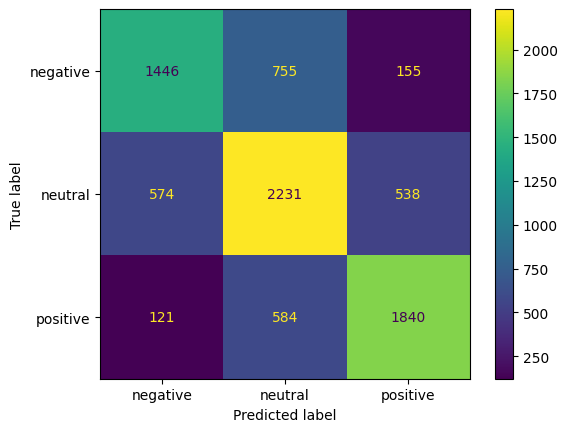

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=text_clf.classes_)
disp.plot()

In [ ]:
text_clf.predict(['This is wery bad! i hate this product. do not recommend'])

array(['negative'], dtype=object)

Code is modified from the found code in moodle.
I used Gemini as help with places i was stuck on.